In [1]:
!pip install kagglehub
!pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import pickle


 MODEL 1 — Fraud Transaction Detection

 Purpose

Detects suspicious financial transactions during land registration.

Example:

Fake payment

Money laundering

Illegal land transfer

This protects blockchain land transactions.

In [3]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Dataset path:", path)

data = pd.read_csv(path + "/creditcard.csv")
data.head()

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Dataset path: /kaggle/input/creditcardfraud


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print("Rows:", data.shape[0])
print("Columns:", data.shape[1])

data.describe()

Rows: 284807
Columns: 31


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [5]:
#Preprocessing
X = data.drop("Class", axis=1)
y = data["Class"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
model = Sequential()

model.add(Dense(32, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2849/2849 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9953 - loss: 0.0440 - val_accuracy: 0.9993 - val_loss: 0.0033
Epoch 2/10
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9995 - loss: 0.0028 - val_accuracy: 0.9993 - val_loss: 0.0031
Epoch 3/10
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9995 - loss: 0.0025 - val_accuracy: 0.9994 - val_loss: 0.0030
Epoch 4/10
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9994 - loss: 0.0028 - val_accuracy: 0.9994 - val_loss: 0.0030
Epoch 5/10
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9995 - loss: 0.0021 - val_accuracy: 0.9994 - val_loss: 0.0032
Epoch 6/10
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9995 - loss: 0.0022 - val_accuracy: 0.9995 - val_loss: 0.0030
Epoch 7/10
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9995 - loss: 0.0020 - val_accuracy: 0.9994 - val_loss: 0.0032
Epoch 8/10
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9995 - loss: 0.0021 - val_accurac

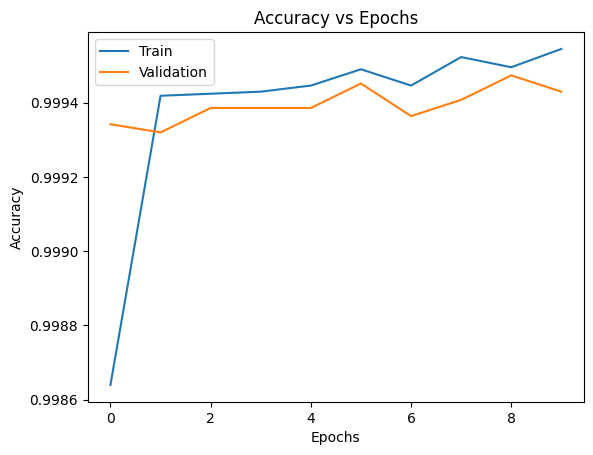

In [7]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

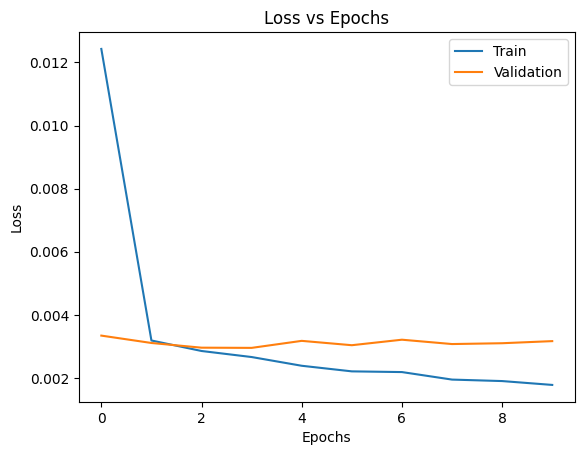

In [8]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


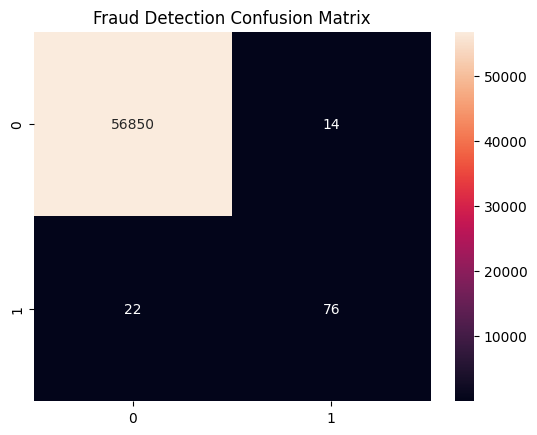

In [9]:
pred = (model.predict(X_test) > 0.5)

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Fraud Detection Confusion Matrix")
plt.show()

In [10]:
model.save("fraud_model.h5")

MODEL 2 — Ownership Conflict Detection

Purpose

Detects duplicate or conflicting land ownership records.

Example:

Two people claiming same land

Fake ownership transfers

Land disputes

Helps the blockchain prevent double registration

In [11]:
path = kagglehub.dataset_download("kartik2112/fraud-detection")

data = pd.read_csv(path + "/fraudTrain.csv")
data.head()

100%|██████████| 202M/202M [00:01<00:00, 108MB/s]

Extracting files...


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [12]:
print(data.shape)
data.describe()

(1296675, 23)


,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [13]:
#preprocessing
data = data.select_dtypes(include=['int64','float64'])

X = data.drop("is_fraud", axis=1)
y = data["is_fraud"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [14]:
from sklearn.ensemble import RandomForestClassifier

model2 = RandomForestClassifier(n_estimators=100)

model2.fit(X_train,y_train)

pred = model2.predict(X_test)

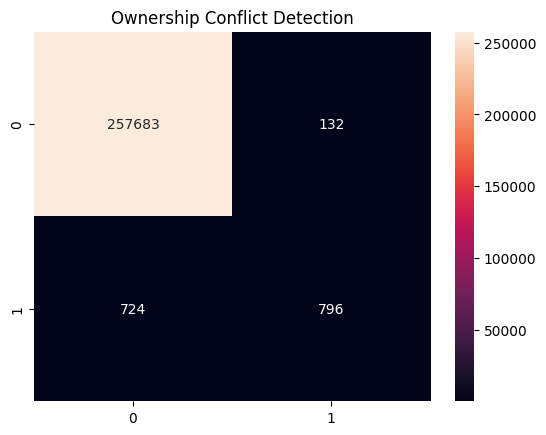

In [15]:
cm = confusion_matrix(y_test,pred)

sns.heatmap(cm,annot=True,fmt="d")
plt.title("Ownership Conflict Detection")
plt.show()

In [16]:
pickle.dump(model2,open("ownership_model.pkl","wb"))

MODEL 3 — Land Price Prediction

Purpose

Predicts realistic land price based on:

Area

Location

Amenities

Infrastructure

Helps detect overpriced or suspicious land deals.

In [17]:
path = kagglehub.dataset_download("amitabhajoy/bengaluru-house-price-data")

data = pd.read_csv(path + "/Bengaluru_House_Data.csv")
data.head()

100%|██████████| 195k/195k [00:00<00:00, 37.5MB/s]

Extracting files...


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [43]:
# Convert size column to string first
data['size'] = data['size'].astype(str)

# Extract BHK number
data['bhk'] = data['size'].str.extract(r'(\d+)')

# Convert to numeric
data['bhk'] = data['bhk'].astype(float)

data[['size','bhk']].head()

,size,bhk
0,2,2.0
1,4,4.0
3,3,3.0
5,2,2.0
11,4,4.0


In [44]:
def convert_sqft(x):
    if '-' in str(x):
        tokens = x.split('-')
        return (float(tokens[0]) + float(tokens[1])) / 2
    try:
        return float(x)
    except:
        return None

data['total_sqft'] = data['total_sqft'].apply(convert_sqft)

In [45]:
data = data.drop(['area_type','availability','society','size'], axis=1)

In [46]:
data = data.dropna()

In [48]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['location'] = le.fit_transform(data['location'])

In [50]:
X = data[['location','total_sqft','bath','balcony','bhk']]
y = data['price']
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [52]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=200)

model.fit(X_train,y_train)

RandomForestRegressor(n_estimators=200)

In [53]:
pred = model.predict(X_test)

In [54]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
r2 = r2_score(y_test,pred)
rmse = np.sqrt(mean_squared_error(y_test,pred))
mae = mean_absolute_error(y_test,pred)

print("R2 Score:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

R2 Score: 0.5875935789816311
RMSE: 72.1761819854333
MAE: 21.804548098039955


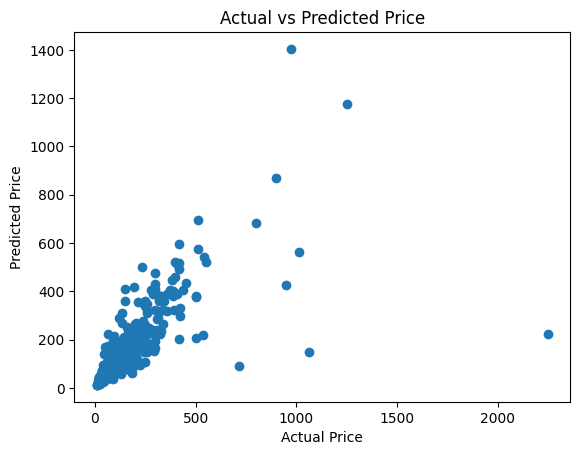

In [55]:
plt.scatter(y_test,pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

In [56]:
import pickle

pickle.dump(model,open("price_model.pkl","wb"))

MODEL 4 — AI Risk Score Engine

 Purpose

Combines outputs from all models to produce a final risk score for a land transaction.

Example:

Component	Risk
Fraud detection	0.2
Ownership conflict	0.4
Price anomaly	0.3

Final Risk Score = 0.9 (High Risk)

In [25]:
def calculate_risk(fraud_prob, ownership_flag, price_deviation):

    risk = (
        fraud_prob * 0.5 +
        ownership_flag * 0.3 +
        price_deviation * 0.2
    )

    return risk

In [26]:
with open("risk_engine.pkl","wb") as f:
    pickle.dump(calculate_risk,f)